# Redes Neurais Artificiais com Keras

**Francisco Aparecido Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

O **TensorFlow** é uma plataforma de código aberto voltada principalmente para a criação de modelos de aprendizado de máquina (machine learning) e aprendizado profundo (deep learning), desenvolvida pelo **Google**. (https://www.tensorflow.org/?hl=pt-br)

Ele fornece os mecanismos fundamentais para:
- representar dados como tensores;
- realizar operações matriciais;
- calcular derivadas automaticamente;
- executar operações em CPU, GPU ou TPU;
- treinar, salvar e disponibilizar modelos.

Em particular, o TensorFlow implementa a diferenciação automática, usada para calcular os gradientes necessários ao algoritmo de retropropagação.

O **Keras** é a API de alto nível do **TensorFlow** para construir e treinar redes neurais. Ele foi desenhado com um objetivo claro: tornar a criação de redes neurais tão direta quanto possível, sem abrir mão da flexibilidade necessária para arquiteturas sofisticadas. É possível criar a rede mais simples possível até modelos usados em produção por grandes empresas de tecnologia.

Podemos dizer que o Keras é o volante e o painel do carro, enquanto o TensorFlow é o motor.

### Por que usar o Keras (e não só o scikit-learn)?

Já treinamos redes neurais com o `MLPClassifier`/`MLPRegressor` do scikit-learn, vale entender logo de início o que muda:

| Aspecto | scikit-learn | Keras |
|---|---|---|
| Arquitetura da rede | Fixa (só permite empilhar camadas densas, com poucas opções) | Flexível: qualquer número de camadas, tipos variados (densas, convolucionais, recorrentes...) |
| Como se treina | `modelo.fit(X, y)` — uma linha, tudo pronto | `modelo.fit(X, y, epochs=..., batch_size=...)`, ainda uma linha, mas com mais controle explícito |
| Curva de treino | `loss_curve_` (só o conjunto de treino) | `history.history` (treino **e** validação, para qualquer métrica escolhida) |
| Aceleração por GPU | Não suportada | Suportada nativamente |
| Callbacks (parada antecipada, checkpoints...) | Poucas opções fixas | Sistema flexível de *callbacks* |

Ou seja: o Keras mantém a conveniência de um `.fit()` pronto (diferente de bibliotecas como o PyTorch, onde o *loop* de treinamento é escrito manualmente), mas abre a porta para arquiteturas e recursos que o scikit-learn simplesmente não tem.

Dica: Sugiro rodar esse notebook no Colab, já que a instalação do Keras pode exigir a instação de muitos pacotes.

## Conceitos fundamentais do Keras

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # silencia mensagens de log do TensorFlow (não relacionadas a erros)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import tensorflow as tf # importa o tensorflow
tf.get_logger().setLevel("ERROR")
from tensorflow import keras # importa o keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.15.1


### A API `Sequential` e camadas `Dense`

Um modelo Keras é construído empilhando **camadas**. A camada mais básica é a **`Dense`** (densa, ou totalmente conectada): cada neurônio recebe todas as saídas da camada anterior, calcula uma combinação linear ponderada e aplica uma **função de ativação**. As ativações mais comuns:

- **`relu`**: $\max(0, x)$ — a mais usada em camadas ocultas, rápida e eficaz;
- **`sigmoid`**: comprime a saída entre 0 e 1 — usada na saída de classificação **binária**;
- **`softmax`**: transforma várias saídas em uma distribuição de probabilidade que soma 1 — usada na saída de classificação **multiclasse**;
- **`linear`** (ou nenhuma ativação): usada na saída de problemas de **regressão**, já que o valor previsto não deve ser artificialmente limitado a um intervalo.

In [3]:
modelo_exemplo = keras.Sequential([
    keras.layers.Input(shape=(2,)),               # camada de entrada: 2 atributos
    keras.layers.Dense(16, activation="relu"),     # 1ª camada oculta
    keras.layers.Dense(12, activation="relu"),     # 2ª camada oculta
    keras.layers.Dense(1, activation="sigmoid"),   # saída: classificação binária
])

modelo_exemplo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265 (1.04 KB)

 Trainable params: 265 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

### Compilando o modelo: `loss`, `optimizer` e `metrics`

Antes de treinar, **compilamos** o modelo, especificando três coisas:

- **`loss`** (função de custo): o que o treinamento tenta minimizar. `'binary_crossentropy'` para classificação binária, `'sparse_categorical_crossentropy'` para classificação multiclasse (com rótulos inteiros), `'mse'` para regressão;
- **`optimizer`**: o algoritmo que ajusta os pesos a cada passo. `'adam'` é a escolha padrão mais robusta;
- **`metrics`**: métricas adicionais para **acompanhar** o treinamento (não usadas para ajustar os pesos, só para reportar o progresso) — `'accuracy'` em classificação, `'mae'` em regressão.

In [4]:
modelo_exemplo.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

### Treinando: `.fit(...)` e o objeto `history`

O treinamento é feito com `.fit(X, y, epochs=..., batch_size=..., validation_data=...)`:

- **`epochs`**: quantas vezes o algoritmo percorre todo o conjunto de treinamento;
- **`batch_size`**: quantos exemplos são usados para calcular cada atualização dos pesos;
- **`validation_data`** (ou `validation_split`): dados usados, ao final de cada época, para medir o desempenho em exemplos que o modelo não usou para treinar. É essencial para detectar sobreajuste (*overfitting*).

O `.fit(...)` devolve um objeto `history`, cujo atributo `history.history` é um dicionário com a perda (e as métricas escolhidas) de treino e validação, **por época**. É a base de todos os gráficos que vamos usar neste notebook.

## Aplicando o Keras a dados artificiais

Antes de ir para dados reais, vale construir intuição em problemas **artificiais**, onde conhecemos exatamente o padrão gerador dos dados e podemos visualizar tudo com clareza. Isto é, a rede realmente aprendeu o padrão, ou só decorou pontos específicos?

### Classificação: dois círculos concêntricos

Vamos gerar um problema clássico de classificação **não linear**: uma classe formando um círculo interno, outra formando um anel ao redor. Nenhuma reta separa bem essas classes. É um bom teste para verificar se vale a pena usar camadas ocultas.

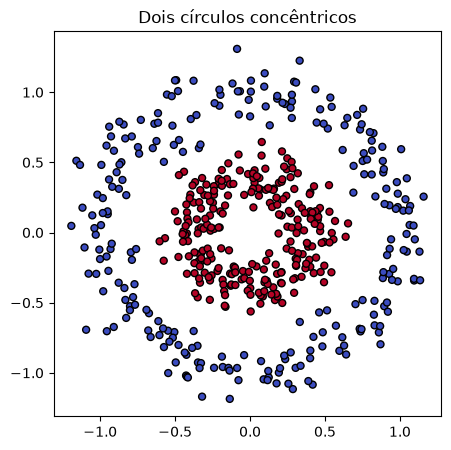

In [5]:
from sklearn.datasets import make_circles

# Gera 500 observações distribuídas em dois círculos.
# factor=0.4: define o raio do círculo interno como 40% do raio do círculo externo.
X_circ, y_circ = make_circles(n_samples=500, noise=0.1, factor=0.4, random_state=42)

# Divide os dados em conjuntos de treinamento e teste.
X_circ_train, X_circ_test, y_circ_train, y_circ_test = train_test_split(
    X_circ, y_circ, test_size=0.2, random_state=42, stratify=y_circ
)
# Cria o escalonador e calcula a média e o desvio-padrão
escalonador_circ = StandardScaler().fit(X_circ_train)
X_circ_train = escalonador_circ.transform(X_circ_train)
X_circ_test = escalonador_circ.transform(X_circ_test)

# Mostra os dados
plt.figure(figsize=(5, 5))
plt.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap="coolwarm", edgecolors="k", s=25)
plt.title("Dois círculos concêntricos")
plt.show()

Vamos comparar dois modelos: um **sem** camada oculta (equivalente a um classificador linear) e um **com** duas camadas ocultas.

In [6]:
# Define uma semente para tornar a inicialização dos pesos e o treinamento mais reproduzíveis.
tf.random.set_seed(42)

############# Modelo sem camada oculta #############
# Como existe apenas uma camada de saída, esse modelo é equivalente
# a uma regressão logística. Portanto, ele produz uma fronteira de decisão linear.
modelo_linear = keras.Sequential([
    # Define que cada observação possui dois atributos de entrada: as coordenadas x1 e x2 dos pontos.
    keras.layers.Input(shape=(2,)),
    # Camada de saída com um único neurônio.
    # A função sigmoid transforma a saída em um valor entre 0 e 1,
    # que pode ser interpretado como a probabilidade de pertencer à classe positiva.
    keras.layers.Dense(
        units=1,
        activation="sigmoid"
    )
])
# Configura o processo de treinamento do modelo linear.
modelo_linear.compile(
    # Adam é o algoritmo utilizado para atualizar os pesos.
    optimizer="adam",
    # Binary cross-entropy é adequada para problemas de classificação com duas classes.
    loss="binary_crossentropy",
    # A acurácia será calculada durante o treinamento.
    metrics=["accuracy"]
)
# Treina o modelo sem camada oculta.
hist_linear = modelo_linear.fit(
    # Dados utilizados para ajustar os pesos.
    X_circ_train,
    y_circ_train,
    # Número de vezes que o modelo percorre todo o conjunto de treinamento.
    epochs=100,
    # Número de observações utilizadas antes de cada atualização dos pesos.
    batch_size=16,
    # Dados usados para acompanhar o desempenho do modelo durante o treinamento.
    # Dados de validação
    validation_split = 0.2,
    # Evita a exibição do progresso de cada época.
    verbose=0
)
# Avalia o modelo linear no conjunto de teste.
# O método evaluate retorna primeiro a perda e depois as métricas definidas em compile().
# Por isso, o índice [1] corresponde à acurácia.
acc_linear = modelo_linear.evaluate(
    X_circ_test,
    y_circ_test,
    verbose=0
)[1]

# Exibe as acurácias no formato percentual.
print(f"Acurácia sem camada oculta (modelo linear): "f"{acc_linear:.2%}")

############# Modelo perceptron multicamadas, ou MLP #############
tf.random.set_seed(42)
# Diferentemente do modelo anterior, este possui duas camadas ocultas,
# o que permite aprender fronteiras de decisão não lineares.
modelo_mlp = keras.Sequential([
    # Cada observação possui dois atributos de entrada.
    keras.layers.Input(shape=(2,)),
    # Primeira camada oculta com n1 neurônios.
    # A função ReLU introduz não linearidade no modelo.
    keras.layers.Dense(
        units=16,
        activation="relu"
    ),
    # Segunda camada oculta com n2 neurônios.
    keras.layers.Dense(
        units=12,
        activation="relu"
    ),
    # Camada de saída para classificação binária.
    keras.layers.Dense(
        units=1,
        activation="sigmoid"
    )
])
# Configura o treinamento do MLP.
modelo_mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
# Treina o modelo com duas camadas ocultas.
hist_mlp = modelo_mlp.fit(
    X_circ_train,
    y_circ_train,
    epochs=100,
    batch_size=16,
    validation_split = 0.2, # avalia em 20% dos dados de treinamento
    verbose=0
)

# Avalia o MLP no conjunto de teste.
acc_mlp = modelo_mlp.evaluate(
    X_circ_test,
    y_circ_test,
    verbose=0
)[1]

print(f"Acurácia com camadas ocultas (MLP):          "f"{acc_mlp:.2%}")

Acurácia sem camada oculta (modelo linear): 43.00%
Acurácia com camadas ocultas (MLP):          100.00%


### Visualizando a fronteira de decisão e a curva de perda

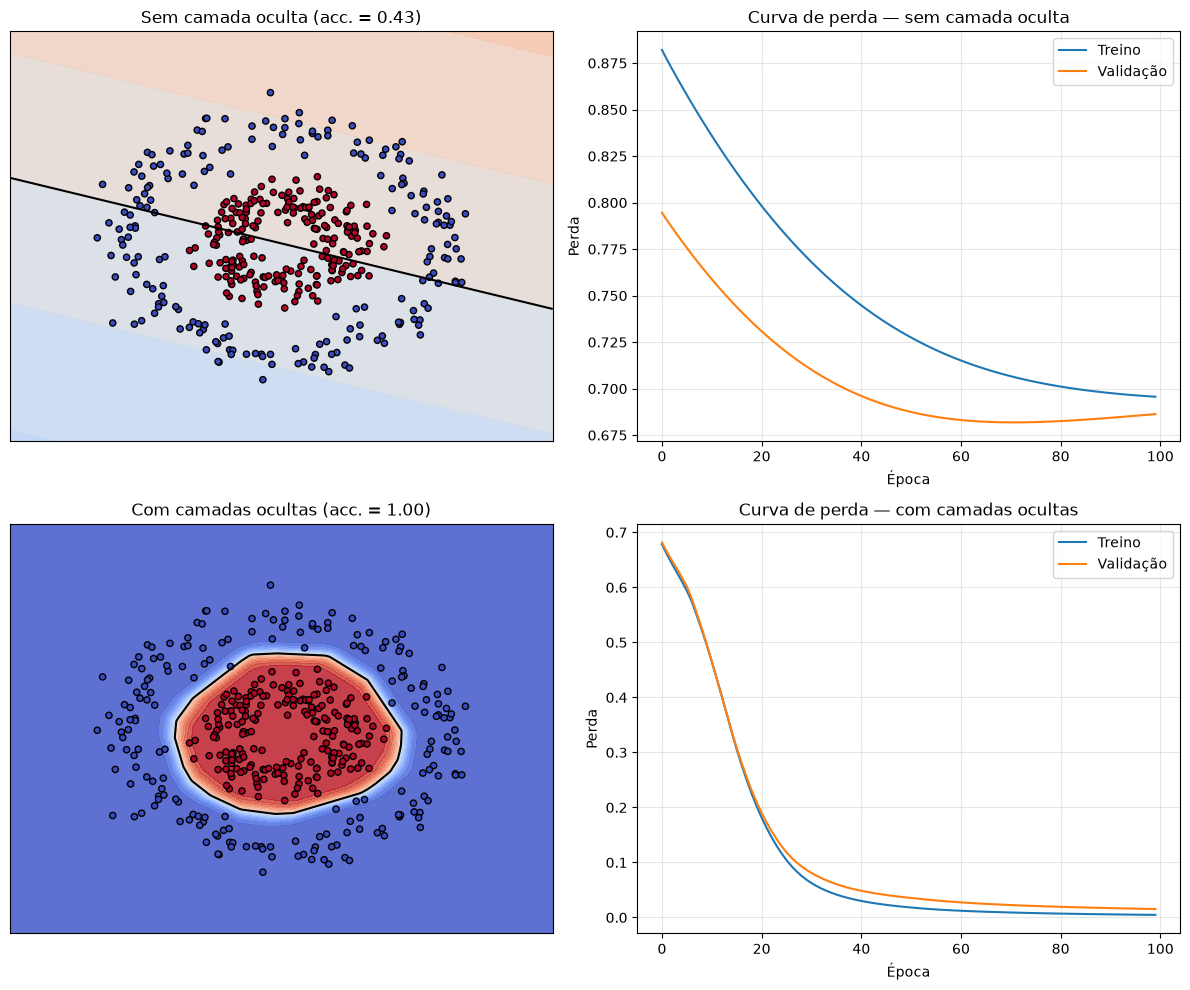

In [7]:
# Função para visualizar a fronteira de decisão de um modelo
def plotar_fronteira(modelo, X, y, ax, titulo, resolucao=200):
    # O valor 1 é subtraído e adicionado para criar uma margem ao redor dos dados no gráfico.
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
     # Cria uma grade regular de pontos sobre o plano.
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, resolucao), np.linspace(x2_min, x2_max, resolucao))
    grade = np.column_stack([xx1.ravel(), xx2.ravel()])
    # Calcula a probabilidade prevista pelo modelo para cada ponto da grade.
    probabilidades = modelo.predict(grade, verbose=0).reshape(xx1.shape)
    # Preenche o fundo do gráfico de acordo com a probabilidade prevista para cada região.
    ax.contourf(xx1, xx2, probabilidades, levels=np.linspace(0, 1, 21), cmap="coolwarm", alpha=0.85)
    # Desenha a fronteira de decisão propriamente dita.
    ax.contour(xx1, xx2, probabilidades, levels=[0.5], colors="black", linewidths=1.5)
    # Sobrepõe os dados reais à região de decisão.
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=20)
    # Define o título do gráfico.
    ax.set_title(titulo)
    # Remove as marcações dos eixos para destacar a geometria da fronteira de decisão.
    ax.set_xticks([]); ax.set_yticks([])

# Cria uma figura com quatro gráficos organizados em duas linhas e duas colunas.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Mostra a fronteira de decisão do modelo linear.
plotar_fronteira(modelo_linear, X_circ_train, y_circ_train, axes[0, 0],
                 f"Sem camada oculta (acc. = {acc_linear:.2f})")
axes[0, 1].plot(hist_linear.history["loss"], label="Treino")
axes[0, 1].plot(hist_linear.history["val_loss"], label="Validação")
axes[0, 1].set_xlabel("Época"); axes[0, 1].set_ylabel("Perda")
axes[0, 1].set_title("Curva de perda — sem camada oculta")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# Mostra a fronteira de decisão do MLP.
plotar_fronteira(modelo_mlp, X_circ_train, y_circ_train, axes[1, 0],
                 f"Com camadas ocultas (acc. = {acc_mlp:.2f})")
axes[1, 1].plot(hist_mlp.history["loss"], label="Treino")
axes[1, 1].plot(hist_mlp.history["val_loss"], label="Validação")
axes[1, 1].set_xlabel("Época"); axes[1, 1].set_ylabel("Perda")
axes[1, 1].set_title("Curva de perda — com camadas ocultas")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

# Ajusta automaticamente os espaços entre os gráficos, evitando sobreposição de títulos e rótulos.
plt.tight_layout()
plt.show()

Sem camada oculta, o modelo só consegue representar uma fronteira **linear**, que é incapaz de separar os círculos. Com camadas ocultas, a rede aprende uma fronteira curva que acompanha o padrão dos dados. Essa é a razão de existir de redes com múltiplas camadas: cada camada oculta permite representar transformações cada vez mais flexíveis dos dados de entrada.

### Regressão

Agora um problema de regressão artificial: vamos gerar pontos ruidosos ao redor de uma curva senoidal, e treinar uma rede para aprender essa curva a partir dos pontos observados.

In [8]:
rng = np.random.default_rng(42)
# Gera n valores aleatórios uniformemente distribuídos no intervalo entre 0 e 10.
n = 400
X_seno = np.sort(rng.uniform(0, 10, n)).reshape(-1, 1)
# Calcula a função seno para cada valor de entrada e adiciona um ruído aleatório com distribuição normal.
y_seno = np.sin(X_seno).ravel() + rng.normal(0, 0.15, X_seno.shape[0])
# Divide os dados em conjuntos de treinamento e teste.
X_seno_train, X_seno_test, y_seno_train, y_seno_test = train_test_split(
    X_seno, y_seno, test_size=0.20, random_state=42
)

# Cria uma rede neural para resolver um problema de regressão.
modelo_seno = keras.Sequential([
    # Define que cada observação possui apenas um atributo de entrada: o valor x usado na função seno.
    keras.layers.Input(shape=(1,)),
    keras.layers.Dense(64, activation="relu"), # Primeira camada oculta com n1 neurônios e ativação ReLU.
    keras.layers.Dense(32, activation="relu"), # Segunda camada oculta, também com n2 neurônios.
    keras.layers.Dense(32, activation="relu"), # Terceira camada oculta, com n3 neurônios.
    keras.layers.Dense(1, activation="linear"),   # saída contínua: sem ativação
])
# Configura o processo de treinamento da rede.
modelo_seno.compile(optimizer="adam", loss="mse", metrics=["mae"])
# Treina a rede neural.
hist_seno = modelo_seno.fit(X_seno_train, y_seno_train,
                            epochs=200,
                            batch_size=16,
                            validation_split = 0.2,
                            verbose=0)

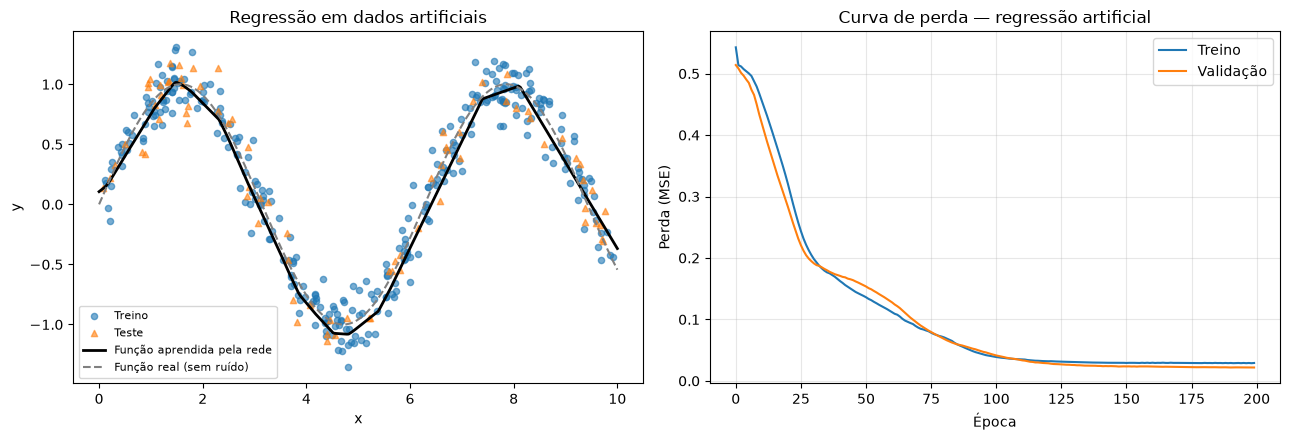

In [9]:
# Cria 300 valores igualmente espaçados no intervalo entre 0 e 10.
X_plot = np.linspace(0, 10, 300).reshape(-1, 1)
# Usa o modelo treinado para prever o valor de y
y_plot = modelo_seno.predict(X_plot, verbose=0)

# Cria uma figura contendo dois gráficos lado a lado.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
# Exibe as observações utilizadas no treinamento.
ax1.scatter(X_seno_train, y_seno_train, s=20, alpha=0.6, label="Treino")
# Exibe as observações do conjunto de teste.
ax1.scatter(X_seno_test, y_seno_test, s=20, alpha=0.6, label="Teste", marker="^")
# Desenha a função aprendida pela rede neural.
ax1.plot(X_plot, y_plot, color="black", linewidth=2, label="Função aprendida pela rede")
# Desenha a função seno verdadeira, sem o ruído adicionado aos dados.
ax1.plot(X_plot, np.sin(X_plot), color="gray", linestyle="--", linewidth=1.5, label="Função real (sem ruído)")
# Define os rótulos dos eixos.
ax1.set_xlabel("x"); ax1.set_ylabel("y")
ax1.set_title("Regressão em dados artificiais")
ax1.legend(fontsize=8)

# Exibe o erro quadrático médio no conjunto de treinamento ao final de cada época.
ax2.plot(hist_seno.history["loss"], label="Treino")
ax2.plot(hist_seno.history["val_loss"], label="Validação")
ax2.set_xlabel("Época"); ax2.set_ylabel("Perda (MSE)")
ax2.set_title("Curva de perda — regressão artificial")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

A rede aprendeu a se aproximar bastante da função seno original, mesmo tendo visto apenas pontos ruidosos. Ela conseguiu "filtrar" boa parte do ruído e capturar o padrão real subjacente. Essa é a tarefa central de qualquer modelo de regressão: separar sinal de ruído. Vamos agora aplicar exatamente as mesmas ideias a problemas reais.

## 3 - Classificação em dados reais

Vamos aplicar o Keras a um problema real de classificação **multiclasse**: identificar a categoria de um veículo (ônibus, van, ou um de dois modelos de carro) a partir de 18 atributos geométricos extraídos da silhueta do veículo em uma imagem.

In [10]:
# Na aula o professo baixou os dados do Google drive
# from google.colab import drive

# Mount Google Drive
# drive.mount('/content/drive')
caminho = r"C:\Users\User\OneDrive\Documentos\CursoMLeCD-USP\data\Vehicle.csv"

dados = pd.read_csv(caminho, header=(0))
# se for rodar offline, descomente a seguir
# dados = pd.read_csv("data/Vehicle.csv")
print("Dimensão dos dados:", dados.shape)
dados.head()

Dimensão dos dados: (846, 19)


,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus


Distribuição das classes:


Class
bus     218
saab    217
opel    212
van     199
Name: count, dtype: int64

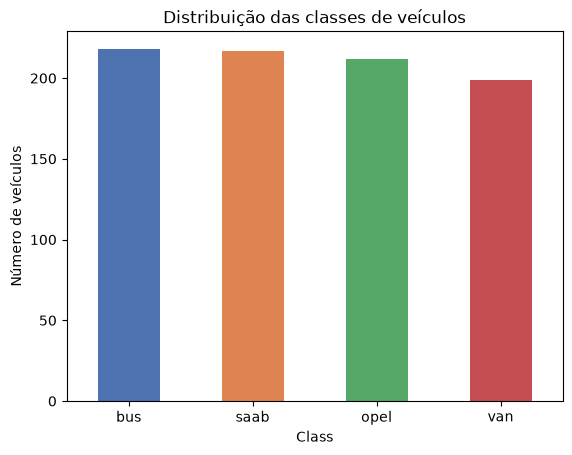

In [11]:
print("Distribuição das classes:")
display(dados["Class"].value_counts())

dados["Class"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
plt.xticks(rotation=0)
plt.ylabel("Número de veículos")
plt.title("Distribuição das classes de veículos")
plt.show()

### Preparando os dados

Como o alvo é categórico (texto), o convertemos em inteiros com `LabelEncoder`. Depois, escalonamos os atributos. Esse passo é essencial para redes neurais, já que atributos em escalas muito diferentes fazem com que o treinamento fique dominado pelos atributos de maior magnitude.

In [12]:
# Separa os atributos preditores da variável resposta.
X = (dados.drop(columns=["Class"]).to_numpy().astype("float32"))
# Cria um codificador para transformar os nomes das classes em valores inteiros.
le = LabelEncoder()
# Ajusta o codificador às classes existentes e realiza a transformação.
y = le.fit_transform(dados["Class"])
# Exibe o mapeamento entre os nomes originais das classes e os valores inteiros usados pelo modelo.
print("Classes:", dict(zip(le.classes_, range(len(le.classes_)))))

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Classes:", np.unique(y))

# Divide os dados em conjuntos de treinamento e teste.
# Primeira divisão: separa o conjunto de teste.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Cria o escalonador e calcula a média e o desvio-padrão
escalonador = StandardScaler()
escalonador.fit(X_train)
X_train = escalonador.transform(X_train).astype("float32")
X_test = escalonador.transform(X_test).astype("float32")

# Garante que os rótulos sejam vetores unidimensionais contendo números inteiros.
y_train = np.asarray(y_train).astype("int32").ravel()
y_test = np.asarray(y_test).astype("int32").ravel()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Classes: {'bus': 0, 'opel': 1, 'saab': 2, 'van': 3}
Formato de X: (846, 18)
Formato de y: (846,)
Classes: [0 1 2 3]
X_train: (676, 18)
y_train: (676,)
X_test: (170, 18)
y_test: (170,)


### Construindo e treinando o modelo

Para classificação **multiclasse**, a camada de saída tem **um neurônio por classe**, com ativação `softmax`, e usamos `sparse_categorical_crossentropy` como função de custo (aceita os rótulos como inteiros diretamente, sem precisar de codificação *one-hot*).

In [13]:
# Cria uma rede neural sequencial para classificação multiclasse.
# Em um modelo Sequential, as camadas são organizadas em sequência:
# a saída de uma camada é utilizada como entrada da camada seguinte.
modelo_vehicle = keras.Sequential([
    # X_train.shape[1] corresponde ao número de atributos presentes no conjunto de dados.
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation="relu"), # Primeira camada oculta, composta por n1 neurônios.
    keras.layers.Dense(64, activation="relu"), # Segunda camada oculta, também com n2 neurônios e ativação ReLU.
    # A função softmax transforma as saídas em probabilidades.
    keras.layers.Dense(len(le.classes_), activation="softmax"), # Camada de saída da rede.
])

# Configura o processo de treinamento da rede neural.
modelo_vehicle.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
# Exibe um resumo da arquitetura da rede.
modelo_vehicle.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,636 (22.02 KB)

 Trainable params: 5,636 (22.02 KB)

 Non-trainable params: 0 (0.00 B)

### Parada antecipada: um recurso do Keras sem equivalente direto no scikit-learn

Em vez de escolher um número fixo de épocas de maneira arbitrária, vamos usar o callback **`EarlyStopping`**: ele monitora a perda de validação e interrompe o treinamento automaticamente quando ela para de melhorar por um número de épocas definido (`patience`), restaurando os pesos da **melhor** época encontrada, não da última.

In [14]:
# Cria um mecanismo de parada antecipada.
parada_antecipada = keras.callbacks.EarlyStopping(
    monitor="val_loss", # Métrica que será acompanhada ao final de cada época.
    patience=20, # Número máximo de épocas consecutivas sem melhora.
    # Ao final do treinamento, recupera os pesos correspondentes à época em que a menor perda de validação foi obtida.
    restore_best_weights=True
)

# Treina a rede neural utilizando o conjunto de treinamento.
# Durante o treinamento:
# - X_train e y_train são usados para calcular a função de perda, os gradientes e atualizar os pesos da rede;
# - X_val e y_val são usados somente para calcular val_loss e val_accuracy ao final de cada época.
historico_vehicle = modelo_vehicle.fit(
    X_train, y_train, # Dados usados para ajustar os pesos da rede.
    epochs=300,
    batch_size=16,# Número de observações processadas antes de cada atualização dos pesos.
    validation_split = 0.2, # avalia em 20% dos dados de treinamento
    # do modelo ao final de cada época. Esses dados não são usados para calcular gradientes
    # nem para atualizar diretamente os pesos.
    callbacks=[parada_antecipada],# Executa o mecanismo de parada antecipada.
    verbose=0
)

# Recupera o número de épocas efetivamente executadas.
# O histórico contém um valor da função de perda para cada época.
# Portanto, o comprimento da lista "loss" corresponde ao número de épocas realizadas.
n_epocas_treinadas = len(historico_vehicle.history["loss"])
acc_final = modelo_vehicle.evaluate(X_test, y_test, verbose=0)[1]
print(f"Número de épocas treinadas: {n_epocas_treinadas} (de até 300 permitidas)")
print(f"Acurácia final no conjunto de teste: {acc_final:.2%}")

Número de épocas treinadas: 60 (de até 300 permitidas)
Acurácia final no conjunto de teste: 81.18%


### Curva de épocas $\times$ função de custo

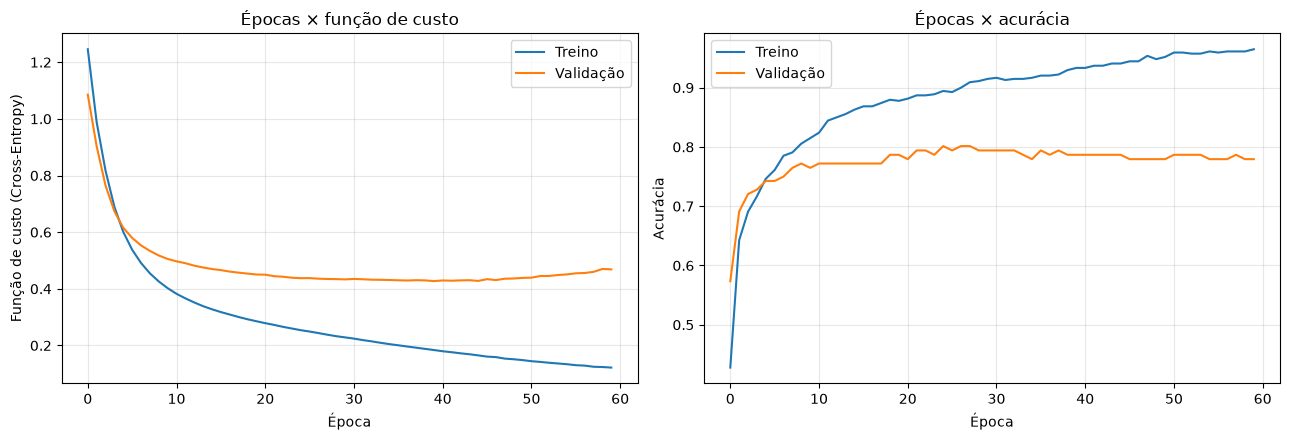

In [15]:
# Cria uma figura com dois gráficos posicionados lado a lado.
fig, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(13, 4.5))
# eixo1 será usado para mostrar a evolução da função de custo.
# eixo2 será usado para mostrar a evolução da acurácia.
# Exibe a função de custo calculada no conjunto de treinamento ao final de cada época.
eixo1.plot(historico_vehicle.history["loss"], label="Treino")
# Exibe a função de custo calculada no conjunto de validação.
eixo1.plot(historico_vehicle.history["val_loss"], label="Validação")
# Define os rótulos dos eixos.
eixo1.set_xlabel("Época"); eixo1.set_ylabel("Função de custo (Cross-Entropy)")
eixo1.set_title("Épocas × função de custo")
eixo1.legend(); eixo1.grid(alpha=0.3)

# Exibe a acurácia obtida no conjunto de treinamento ao final de cada época.
eixo2.plot(historico_vehicle.history["accuracy"], label="Treino")
# Exibe a acurácia calculada no conjunto de validação.
eixo2.plot(historico_vehicle.history["val_accuracy"], label="Validação")
eixo2.set_xlabel("Época"); eixo2.set_ylabel("Acurácia")
eixo2.set_title("Épocas × acurácia")
eixo2.legend(); eixo2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Avaliação: matriz de confusão e relatório de classificação

              precision    recall  f1-score   support

         bus     1.0000    1.0000    1.0000        44
        opel     0.6154    0.7619    0.6809        42
        saab     0.7059    0.5455    0.6154        44
         van     0.9500    0.9500    0.9500        40

    accuracy                         0.8118       170
   macro avg     0.8178    0.8143    0.8116       170
weighted avg     0.8171    0.8118    0.8098       170



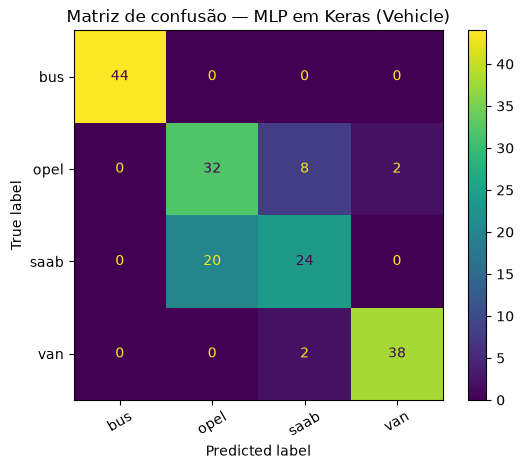

In [16]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Calcula as probabilidades previstas pelo modelo para cada observação do conjunto de teste.
probabilidades = modelo_vehicle.predict(X_test,verbose=0)
# Identifica, para cada observação, o índice da classe com a maior probabilidade prevista.
y_pred = probabilidades.argmax(axis=1)

# Converte os códigos numéricos previstos de volta para os nomes originais das classes.
# Por exemplo:
# 0 → bus
# 1 → opel
# 2 → saab
y_pred_labels = le.inverse_transform(y_pred)
# Converte também os códigos das classes verdadeiras para seus nomes originais.
y_test_labels = le.inverse_transform(y_test)

# Exibe o relatório de classificação.
print(classification_report(y_test_labels, y_pred_labels, digits=4))

# Constrói a matriz de confusão a partir das classes verdadeiras e das classes previstas.
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels, xticks_rotation=30)
plt.title("Matriz de confusão — MLP em Keras (Vehicle)")
plt.show()

As classes `bus` e `van` costumam ser identificadas quase perfeitamente, enquanto `opel` e `saab` (dois modelos de carro) são mais frequentemente confundidos entre si — uma característica conhecida deste conjunto de dados: as silhuetas desses dois modelos são, de fato, muito parecidas do ponto de vista das medidas geométricas usadas como atributos.

## Regressão em dados reais

Agora vamos aplicar o Keras a um problema real de **regressão**: prever a resistência à compressão do concreto (em MPa) a partir de 8 atributos da composição da mistura (quantidade de cimento, água, idade da mistura em dias, entre outros).

In [17]:
# from google.colab import drive

# # Mount Google Drive
# drive.mount('/content/drive')
caminho = r"C:\Users\User\OneDrive\Documentos\CursoMLeCD-USP\data\concrete_data.csv"

df = pd.read_csv(caminho, header=(0))
# se for rodar offline, descomente a seguir
# df = pd.read_csv("data/concrete_data.csv")
print("Dimensão dos dados:", dados.shape)
dados.head()

Dimensão dos dados: (846, 19)


,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus


In [18]:
alvo = df.columns[-1]

print(df[alvo].describe())

count    1030.000000
mean       35.817961
std        16.705742
min         2.330000
25%        23.710000
50%        34.445000
75%        46.135000
max        82.600000
Name: concrete_compressive_strength, dtype: float64


### Preparando os dados e construindo o modelo

A arquitetura é quase idêntica à da classificação, com duas diferenças: a camada de saída tem **um único neurônio, sem ativação** (produzindo diretamente um valor numérico contínuo), e a função de custo passa a ser `'mse'` (erro quadrático médio), acompanhada por `'mae'` (erro absoluto médio) como métrica auxiliar.

In [19]:
# Separa a matriz de atributos (X), removendo a coluna da variável alvo,
# e converte os dados para o tipo float32, que é o formato mais eficiente
# para treinamento de redes neurais.
X = df.drop(columns=[alvo]).to_numpy().astype("float32")
# Extrai a variável resposta (y) e também a converte para float32.
y = df[alvo].to_numpy().astype("float32")

# Divide os dados em conjuntos de treinamento e teste.
# Primeira divisão: separa o conjunto de teste.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

# Cria o escalonador e calcula a média e o desvio-padrão
escalonador = StandardScaler()
escalonador.fit(X_train)
X_train = escalonador.transform(X_train).astype("float32")
X_test = escalonador.transform(X_test).astype("float32")

# Garante que os rótulos sejam vetores unidimensionais contendo números inteiros.
y_train = np.asarray(y_train).astype("int32").ravel()
y_test = np.asarray(y_test).astype("int32").ravel()


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (824, 8)
y_train: (824,)
X_test: (206, 8)
y_test: (206,)


In [20]:
# Define uma rede neural do tipo feedforward (MLP) usando a API Sequential.
modelo_concreto = keras.Sequential([
    # Camada de entrada com uma unidade para cada atributo do conjunto de dados.
    keras.layers.Input(shape=(X_train.shape[1],)),
    # Primeira camada oculta com 128 neurônios e função de ativação ReLU.
    # Essa camada aprende representações intermediárias dos dados.
    keras.layers.Dense(128, activation="relu"),
    # Segunda camada oculta com 64 neurônios, também utilizando ReLU.
    # Ela combina as características aprendidas pela camada anterior para modelar relações mais complexas.
    keras.layers.Dense(64, activation="relu"),
    # Terceira camada oculta com 32 neurônios, também utilizando ReLU.
    keras.layers.Dense(32, activation="relu"),
    # Camada de saída com um único neurônio e ativação linear.
    # Como o problema é de regressão, a saída deve assumir qualquer valor real, sem restrições de intervalo.
    keras.layers.Dense(1, activation="linear"),
])
# Configura o processo de treinamento da rede.
modelo_concreto.compile(optimizer="adam", loss="mse", metrics=["mae"])
# Exibe um resumo da arquitetura da rede, mostrando as camadas,
# o número de parâmetros treináveis e o formato das saídas.
modelo_concreto.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Configura o mecanismo de parada antecipada (Early Stopping).
parada_antecipada_r = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=50, # Permite que a rede continue treinando por até n épocas sem melhora antes de interromper o treinamento.
    # Ao final do treinamento, restaura automaticamente os pesos da
    # época que apresentou o menor erro de validação, e não os da última época executada.
    restore_best_weights=True
)

# Inicia o treinamento da rede neural.
historico_concreto = modelo_concreto.fit(
    X_train, y_train,
    epochs=500,  # Número máximo de épocas. O treinamento pode terminar antes devido ao Early Stopping.
    batch_size=16, # Número de amostras processadas antes de atualizar os pesos.
    validation_split = 0.2, # avalia em 20% dos dados de treinamento
    callbacks=[parada_antecipada_r], # Lista de callbacks utilizados durante o treinamento.
    verbose=0 # verbose=0 oculta as mensagens produzidas durante o treinamento.
)

# O objeto retornado pelo método fit() armazena o histórico do treinamento,
# incluindo os valores da função de custo e das métricas em cada época.
# O número de elementos da lista "loss" corresponde ao número efetivo de épocas executadas.
n_epocas_treinadas = len(historico_concreto.history["loss"])
print(f"Número de épocas treinadas: {n_epocas_treinadas} (de até 500 permitidas)")

Número de épocas treinadas: 270 (de até 500 permitidas)


### Curva de épocas $\times$ função de custo

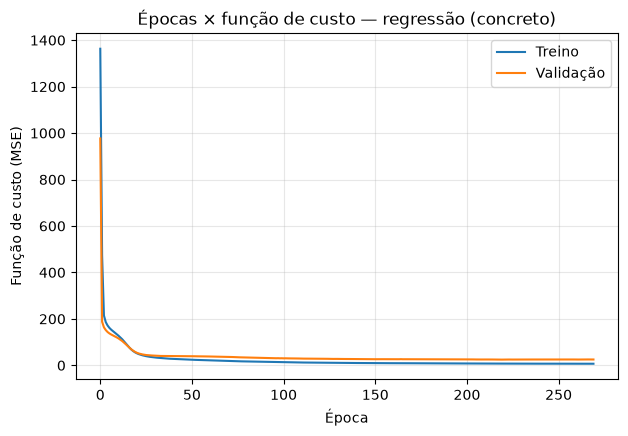

In [22]:
plt.figure(figsize=(7, 4.5))
plt.plot(historico_concreto.history["loss"], label="Treino")
plt.plot(historico_concreto.history["val_loss"], label="Validação")
plt.xlabel("Época"); plt.ylabel("Função de custo (MSE)")
plt.title("Épocas × função de custo — regressão (concreto)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Avaliação: métricas clássicas de regressão

MAE:  4.204
RMSE: 6.276
R²:   0.847


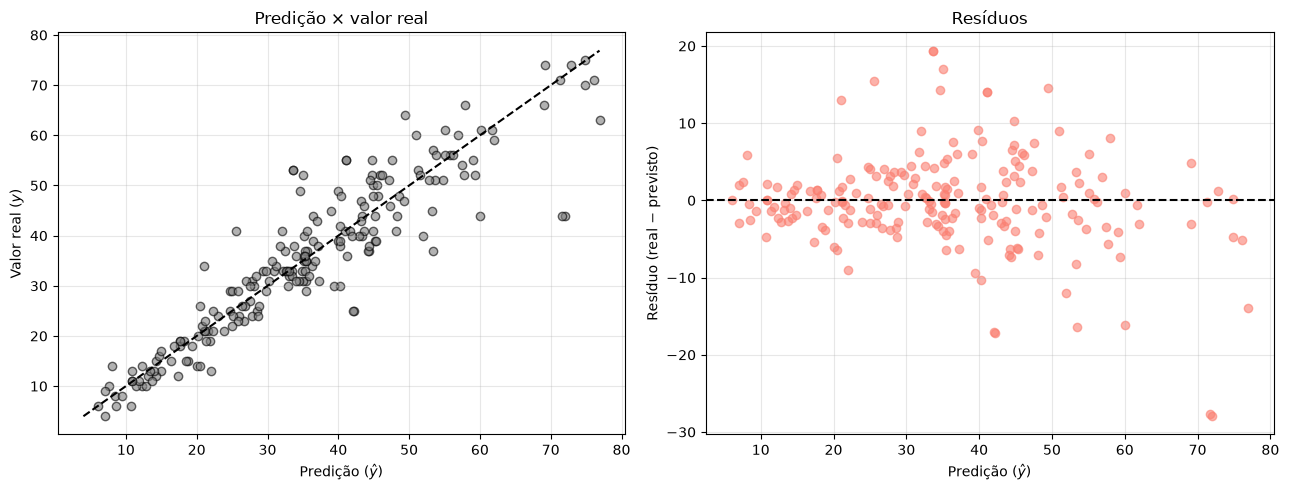

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modelo_concreto.predict(X_test, verbose=0).ravel()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(y_pred, y_test, alpha=0.6, edgecolor="k", color="gray")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax1.plot(lims, lims, "k--")
ax1.set_xlabel(r"Predição ($\hat{y}$)"); ax1.set_ylabel(r"Valor real ($y$)")
ax1.set_title("Predição × valor real")
ax1.grid(alpha=0.3)

residuos = y_test - y_pred
ax2.scatter(y_pred, residuos, alpha=0.6, color="salmon")
ax2.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax2.set_xlabel(r"Predição ($\hat{y}$)"); ax2.set_ylabel("Resíduo (real − previsto)")
ax2.set_title("Resíduos")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

No gráfico da esquerda, quanto mais próximos os pontos estiverem da linha tracejada, melhor o modelo. No gráfico da direita, queremos que os resíduos estejam espalhados aleatoriamente ao redor de zero, sem nenhum padrão sistemático — um formato de funil ou uma tendência clara indicaria que o modelo está errando de um jeito previsível, algo que atributos adicionais ou uma arquitetura diferente poderiam corrigir.

### Exercícios de fixação

1. Repita a comparação entre o modelo sem camada oculta e o MLP usando `make_moons` (do scikit-learn) no lugar de `make_circles`. O mesmo padrão se repete?


2. Treine um segundo modelo de regressão com uma rede maior (por exemplo, camadas de 256 e 128 neurônios) e sem o `EarlyStopping`, deixando-o treinar por todas as 500 épocas. A perda de validação piora em algum ponto? Isso seria um sinal de overfitting?

3. Repita a classificação usando `activation="tanh"` no lugar de `"relu"` nas camadas ocultas. O tempo de treinamento ou a acurácia final mudam de forma perceptível?

### Material Adicional
[Deep Learning with python - deep dive on Keras](https://deeplearningwithpython.io/chapters/chapter07_deep-dive-keras/)